In [1]:
from eregion.tasks import ImageCreator, ImageResult
from eregion.tasks.custom import guess_image_type_from_filename_DEIMOS, load_image_fits_DEIMOS
from eregion.tasks.calibration import MasterBias, CalibrationResult
from eregion.tasks.preprocessing import BiasSubtraction, ScanSubtraction, SigmaClipMasking

import numpy as np
import matplotlib.pyplot as plt
import os
import glob2
from copy import deepcopy
import importlib

# Example: DEIMOS science focal plane characterization

In [2]:
basepath = '/Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI'
runid = '20260718*'
rawpath = glob2.glob(os.path.join(basepath, runid))[0]
outpath = rawpath.replace('/DTU_dettest/','/DTU_detreduce/')
if not os.path.exists(outpath):
    os.makedirs(outpath)

### Calproc

In [3]:
# Load bias images
creator = ImageCreator(detector_config = '../eregion/configs/detectors/deimos_sci.yaml')
res = creator.run(input_source = os.path.join(rawpath,'*bias*.fits'),
                  identifier_func = guess_image_type_from_filename_DEIMOS,
                  fileloader_func = load_image_fits_DEIMOS,
                  data_on_demand = True)

# make master bias
master_bias_task = MasterBias(method='median')
mb_res = master_bias_task.run(bias_images=res.data('type == "bias"'))


2026-07-24 11:07:36,436 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-24 11:07:36,437 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718-001407/*bias*.fits is a glob pattern
2026-07-24 11:07:48,513 - MasterBias - INFO - Setting method 'median' for task MasterBias.


In [4]:
# cleanup memory
del res
# save master bias result obj
mb_res.save(outpath)

In [5]:
# load master bias result obj
mb_res = CalibrationResult.load(outpath)
mb_res.master_bias

,type,exptime,det_id,filename,object
0,master_bias,0.0,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10c434550>
1,master_bias,0.0,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x11802b610>
2,master_bias,0.0,det_3,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10caae670>
3,master_bias,0.0,det_4,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x11802af30>
4,master_bias,0.0,det_5,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x11802a7b0>
5,master_bias,0.0,det_6,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x11802be30>
6,master_bias,0.0,det_7,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x10b64b070>
7,master_bias,0.0,det_8,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x114366490>


### Preproc

Sanity checks for each step

In [6]:
def quick_plot(img):
    vmin, vmax = np.percentile(img.data.values, [5, 95])
    img.show(cmap='gray', vmin=vmin, vmax=vmax, origin='lower')

2026-07-24 11:08:04,686 - datamodels.image - WARNING - Mask key 'sigma_clip_mask' not found in DetImage masks. Showing unmasked data.


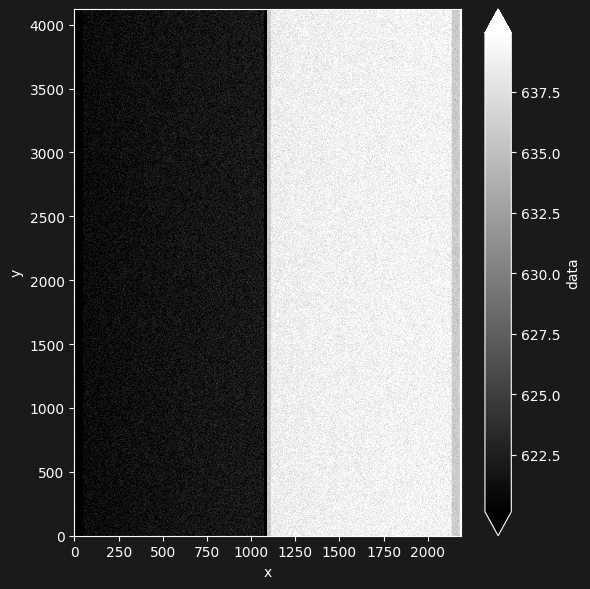

In [7]:
# plot master bias
quick_plot(mb_res.master_bias[0])

In [8]:
## Loadig first pair at exptime 0
creator = ImageCreator(detector_config='../eregion/configs/detectors/deimos_sci.yaml', max_batch_size=2)

flpair = creator.run(input_source='/Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*SCI_1_flat_0.032*.fits',
                  identifier_func=guess_image_type_from_filename_DEIMOS,
                  fileloader_func=load_image_fits_DEIMOS,
                  data_on_demand=True)
flpair.data

2026-07-24 10:25:28,494 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-24 10:25:28,494 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-24 10:25:28,495 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*SCI_1_flat_0.032*.fits is a glob pattern
2026-07-24 10:25:28,495 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*SCI_1_flat_0.032*.fits is a glob pattern


,type,exptime,det_id,filename,object
0,flat,0.032,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x114977a70>
1,flat,0.032,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<datamodels.image.DetImage object at 0x114977570>


2026-07-24 10:25:33,800 - datamodels.image - WARNING - Mask key 'sigma_clip_mask' not found in DetImage masks. Showing unmasked data.


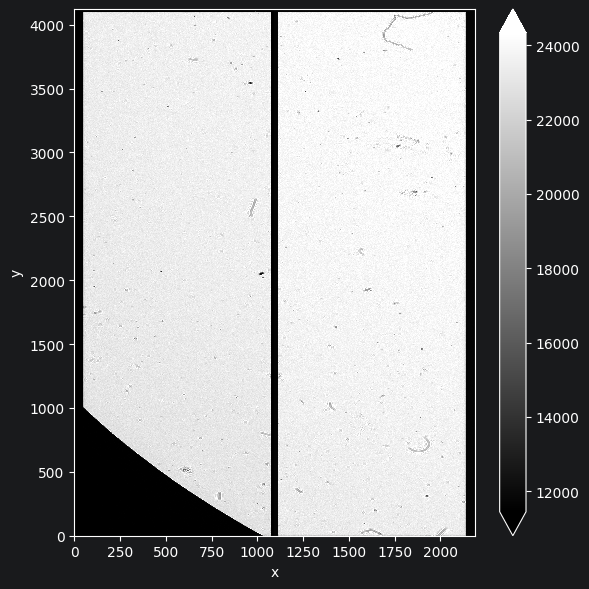

In [9]:
quick_plot(flpair.data[0])

2026-07-24 10:25:42,503 - datamodels.image - WARNING - Mask key 'sigma_clip_mask' not found in DetImage masks. Showing unmasked data.


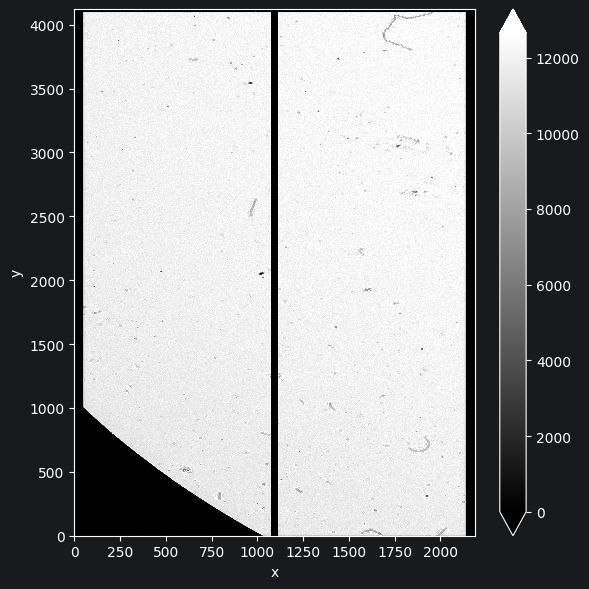

In [10]:
# Do bias sub
bias_sub = BiasSubtraction(quick=True)

after_bs = bias_sub.run(images=deepcopy(flpair.data), master_bias=mb_res.master_bias)
quick_plot(after_bs.data[0])

2026-07-24 10:25:43,312 - ScanSubtraction - INFO - Setting method 'median_by_axis' for task ScanSubtraction.
2026-07-24 10:25:45,613 - datamodels.image - WARNING - Mask key 'sigma_clip_mask' not found in DetImage masks. Showing unmasked data.


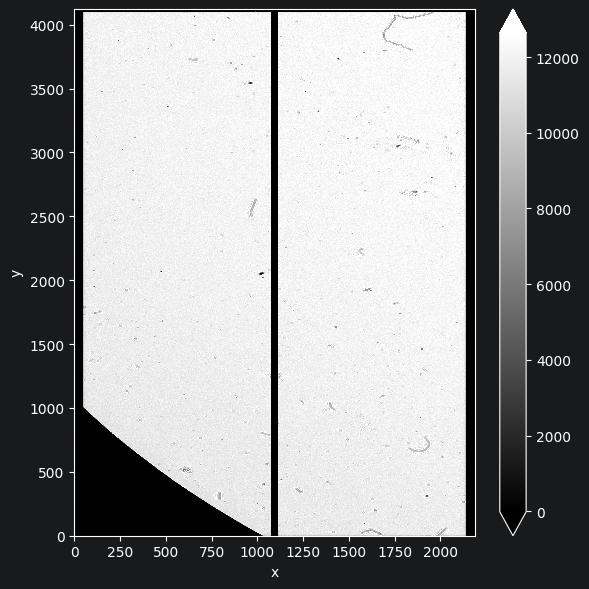

In [11]:
# Do overscan sub
oscan_sub = ScanSubtraction(which_scan='serial_overscan', method='median_by_axis')

after_osub = oscan_sub.run(images=deepcopy(after_bs.data))
quick_plot(after_osub.data[0])

2026-07-24 10:27:10,825 - sigma_clip_masking - INFO - Setting method 'ccd' for task sigma_clip_masking.
2026-07-24 10:27:10,825 - sigma_clip_masking - INFO - Setting method 'ccd' for task sigma_clip_masking.


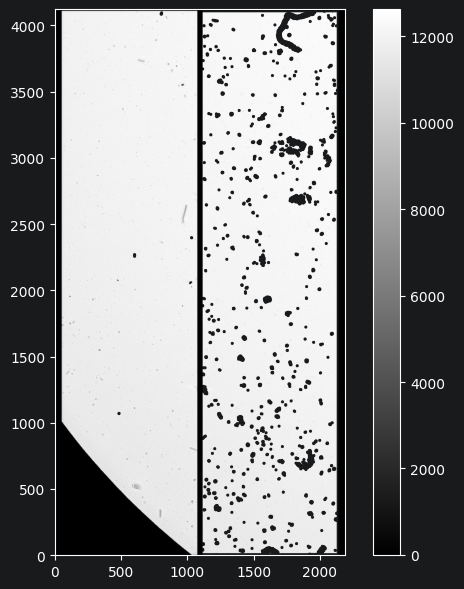

In [14]:
# Do sigma clip
cr_mask = SigmaClipMasking(sigma_clip_args={'sigma_lower':5, 'sigma_upper':5}, n_jobs=1) # set n_jobs=1 to be able to debug in pycharm inside parallelized jobs

after_cr = cr_mask.run(images=deepcopy(after_osub.data))
quick_plot(after_cr.data[0])

In [26]:
# Do PTC
import eregion.tasks.ptc as ptc
importlib.reload(ptc)

ptc_task = ptc.PTC(n_jobs=1)
pres = ptc_task.run(images=deepcopy(after_cr.data))

2026-07-23 21:16:10,899 - PTC - INFO - Doing per output stats on #0 image of 2
2026-07-23 21:16:10,899 - PTC - INFO - Doing per output stats on #0 image of 2
2026-07-23 21:16:11,347 - PTC - INFO - Calculating correlation coefficients
2026-07-23 21:16:11,347 - PTC - INFO - Calculating correlation coefficients
2026-07-23 21:16:12,897 - PTC - INFO - Calculating correlation coefficients
2026-07-23 21:16:12,897 - PTC - INFO - Calculating correlation coefficients
2026-07-23 21:16:13,954 - PTC - INFO - Doing per output stats on #1 image of 2
2026-07-23 21:16:13,954 - PTC - INFO - Doing per output stats on #1 image of 2
2026-07-23 21:16:14,412 - PTC - INFO - Calculating correlation coefficients
2026-07-23 21:16:14,412 - PTC - INFO - Calculating correlation coefficients
2026-07-23 21:16:15,982 - PTC - INFO - Calculating correlation coefficients
2026-07-23 21:16:15,982 - PTC - INFO - Calculating correlation coefficients
2026-07-23 21:16:17,053 - PTC - INFO - Doing diff pair analysis on index 0 a

In [27]:
pres.ptc_table

,n_masked,med,mean,std,mad,skew,kurt,skewtest,skewtestp,kurttest,...,oscan_skewtest,oscan_skewtestp,oscan_kurttest,oscan_kurttestp,PSD,dPSD,det_id,output,exptime,diff
0,9289,3.0,3.292183,28.565125,28.169442,0.062925,0.016826,52.552242,0.000000,6.976207,...,1.399096,1.617843e-01,15.196158,3.749763e-52,"[[221.02653024040004, 71.79678762334899, 74.41...","[[1.2671944157193238, 0.31622174459880237, 0.3...",det_1,E,0.0,False
1,10928,4.0,4.212958,30.116805,30.393345,0.071548,0.020170,59.725006,0.000000,8.347007,...,12.409328,2.325959e-35,48.518433,0.000000e+00,"[[246.77091741483008, 74.8025419182899, 77.854...","[[1.3139585275220407, 0.32540828354796886, 0.3...",det_1,F,0.0,False
2,4720,3.0,3.197858,28.533894,28.169442,0.064773,0.015835,54.121961,0.000000,6.572298,...,2.052068,4.016310e-02,11.104044,1.198937e-28,"[[209.3436435675623, 71.81145842113823, 74.544...","[[1.1856612038390597, 0.31168253885400377, 0.3...",det_1,E,0.0,False
3,10479,4.0,4.157696,30.111881,30.393345,0.071689,0.021143,59.845315,0.000000,8.745841,...,1.936582,5.279652e-02,15.535429,1.997303e-54,"[[242.3874431941723, 75.26507185475184, 78.131...","[[1.2939882813966508, 0.327428764121412, 0.338...",det_1,F,0.0,False
4,11881,0.0,0.091073,35.734876,35.582453,-0.001131,0.017303,-0.945083,0.344616,7.170143,...,0.362306,7.171233e-01,5.296045,1.183378e-07,"[[110.97926211899365, 70.85950041473218, 74.00...","[[0.7014048034119105, 0.30799336620211076, 0.3...",det_1,E,0.0,True
5,20430,0.0,0.049465,37.727084,37.806357,-0.000473,0.017924,-0.394956,0.692875,7.417404,...,5.450549,5.021456e-08,21.458776,3.781305e-102,"[[106.72731710575754, 74.40024016656372, 77.01...","[[0.6787278826607174, 0.31993211483912254, 0.3...",det_1,F,0.0,True


In [28]:
# save to fits
pres.save(outpath)

In [29]:
# load from fits
pres = ptc.PTCResult.load(outpath)
pres.ptc_table

,n_masked,med,mean,std,mad,skew,kurt,skewtest,skewtestp,kurttest,...,oscan_skewtest,oscan_skewtestp,oscan_kurttest,oscan_kurttestp,PSD,dPSD,det_id,output,exptime,diff
0,9289,3.0,3.292183,28.565125,28.169442,0.062925,0.016826,52.552242,0.000000,6.976207,...,1.399096,1.617843e-01,15.196158,3.749763e-52,"[[221.02653024040004, 71.79678762334899, 74.41...","[[1.2671944157193238, 0.31622174459880237, 0.3...",det_1,E,0.0,False
1,10928,4.0,4.212958,30.116805,30.393345,0.071548,0.020170,59.725006,0.000000,8.347007,...,12.409328,2.325959e-35,48.518433,0.000000e+00,"[[246.77091741483008, 74.8025419182899, 77.854...","[[1.3139585275220407, 0.32540828354796886, 0.3...",det_1,F,0.0,False
2,4720,3.0,3.197858,28.533894,28.169442,0.064773,0.015835,54.121961,0.000000,6.572298,...,2.052068,4.016310e-02,11.104044,1.198937e-28,"[[209.3436435675623, 71.81145842113823, 74.544...","[[1.1856612038390597, 0.31168253885400377, 0.3...",det_1,E,0.0,False
3,10479,4.0,4.157696,30.111881,30.393345,0.071689,0.021143,59.845315,0.000000,8.745841,...,1.936582,5.279652e-02,15.535429,1.997303e-54,"[[242.3874431941723, 75.26507185475184, 78.131...","[[1.2939882813966508, 0.327428764121412, 0.338...",det_1,F,0.0,False
4,11881,0.0,0.091073,35.734876,35.582453,-0.001131,0.017303,-0.945083,0.344616,7.170143,...,0.362306,7.171233e-01,5.296045,1.183378e-07,"[[110.97926211899365, 70.85950041473218, 74.00...","[[0.7014048034119105, 0.30799336620211076, 0.3...",det_1,E,0.0,True
5,20430,0.0,0.049465,37.727084,37.806357,-0.000473,0.017924,-0.394956,0.692875,7.417404,...,5.450549,5.021456e-08,21.458776,3.781305e-102,"[[106.72731710575754, 74.40024016656372, 77.01...","[[0.6787278826607174, 0.31993211483912254, 0.3...",det_1,F,0.0,True


### Everything together

In [30]:
creator = ImageCreator(detector_config='../eregion/configs/detectors/deimos_sci.yaml', max_batch_size=2)
bias_sub = BiasSubtraction()
oscan_sub = ScanSubtraction(which_scan='serial_overscan', method='median_by_axis')
cr_mask = SigmaClipMasking(sigma_clip_args={'sigma_lower':5, 'sigma_upper':5})
ptc_task = ptc.PTC()

count = 0
# Load flat images in batches (lazy mode)
for flpair in creator.lazy_run(input_source='/Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*flat*.fits',
                  identifier_func=guess_image_type_from_filename_DEIMOS,
                  fileloader_func=load_image_fits_DEIMOS,
                  data_on_demand=True):
    flpair = bias_sub.run(images=flpair.data, master_bias=mb_res.master_bias)
    flpair = oscan_sub.run(images=flpair.data)
    flpair = cr_mask.run(images=flpair.data)
    ptcres = ptc_task.run(images=flpair.data)

    if count==0:
        preproc_res = flpair
        ptc_res = ptcres
    else:
        preproc_res = preproc_res.combine(flpair)
        ptc_res = ptc_res.combine(ptcres)
    count+=1
    print('Pairs processed: ', count)
    if count>=1:
        break


2026-07-23 21:17:07,675 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-23 21:17:07,675 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-23 21:17:07,675 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-23 21:17:07,675 - DetectorConfig - INFO - Config loaded from file '../eregion/configs/detectors/deimos_sci.yaml'
2026-07-23 21:17:07,677 - ScanSubtraction - INFO - Setting method 'median_by_axis' for task ScanSubtraction.
2026-07-23 21:17:07,677 - ScanSubtraction - INFO - Setting method 'median_by_axis' for task ScanSubtraction.
2026-07-23 21:17:07,677 - ScanSubtraction - INFO - Setting method 'median_by_axis' for task ScanSubtraction.
2026-07-23 21:17:07,677 - sigma_clip_masking - INFO - Setting method 'ccd' for task sigma_clip_masking.
2026-07-23 21:17:07,677 - sigma_clip_masking - INFO - Setting method 'ccd' for task s

Pairs processed:  1


In [31]:
ptc_res.save(outpath)